In [1]:
import sys

sys.path.append("../../..")

import torch
import numpy as np
from collections import Counter
from dataloaders.net import VariantRandomDistributionSampler
from dataloaders.csv_log import CSVEventLogDataset
from dataloaders.xes_log import XESEventLogDataset
from dataloaders.runs import RunDataset, AlignerSpec, SimplePerturbedTraceSampler
from dataloaders.net import ProcessModelDataset
from pm4py.discovery import discover_petri_net_inductive
import matplotlib.pyplot as plt
from util.rng import RNG
import pandas as pd
from pathlib import Path

/Users/paul/dev/pm_ws25/pm4py/pm4py/util/dt_parsing/parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
/Users/paul/dev/pm_ws25/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 100000/100000 [00:10<00:00, 9121.18it/s]


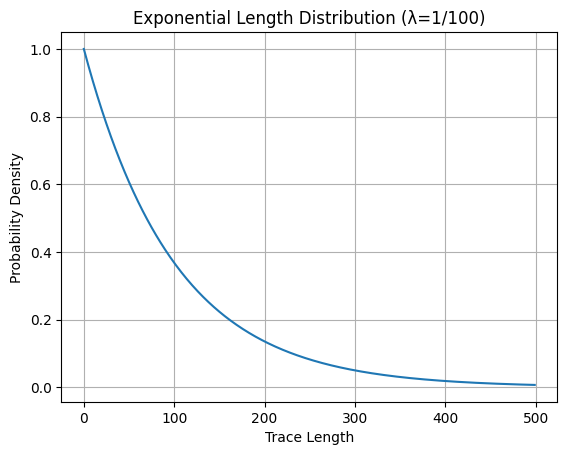

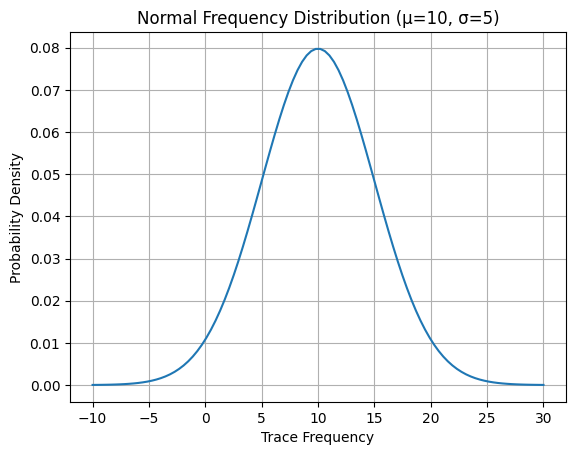

INFO:root:Total discovery configurations generated: 200
INFO:root:Populating process model cache...


kwargs: {'seed': 1}


Caching discovered models: 100%|██████████| 43/43 [01:12<00:00,  1.68s/it]
INFO:root:Cache population done (1904 models).
INFO:root:Populating run dataset cache using 12 workers...
Aligned: 100%|██████████| 50000/50000 [10:43<00:00, 77.66it/s] 


In [ ]:
PLOT = True
N_RUNS = 5  # set number of runs here
path = "../../../data/6af6d5f0-f44c-49be-aac8-8eaa5fe4f6fd/Hospital%20Billing%20-%20Event%20Log.xes"
# path = "../../../data/63a8435a-077d-4ece-97cd-2c76d394d99c/BPIC15_2.xes"
RNG.initialize(1)
log_dataset = XESEventLogDataset(path)

# subset length distribution: defines the distribution of lengths across samples
len_distribution = torch.distributions.Exponential(
    torch.tensor([1.0 / 100.0])
)
mean, std = 10.0, 5.0
freq_distribution = torch.distributions.Normal(
    mean, std
)  # defines the reordering of traces by defining the sampling distribution over index(index)

if PLOT:
    # plot length distribution
    lengths = torch.arange(0, 500)
    probs = torch.exp(-len_distribution.rate * lengths)
    plt.plot(lengths.numpy(), probs.numpy())
    plt.title("Exponential Length Distribution (λ=1/100)")
    plt.xlabel("Trace Length")
    plt.ylabel("Probability Density")
    plt.grid()
    plt.show()

    # plot frequency distribution
    x = torch.linspace(-10, 30, 100)
    coeff = 1.0 / (std * torch.sqrt(torch.tensor(2.0 * 3.141592653589793)))
    exponent = -0.5 * ((x - mean) / std) ** 2
    probs = coeff * torch.exp(exponent)
    plt.plot(x.numpy(), probs.numpy())
    plt.title("Normal Frequency Distribution (μ=10, σ=5)")
    plt.xlabel("Trace Frequency")
    plt.ylabel("Probability Density")
    plt.grid()
    plt.show()

pm_dataset = ProcessModelDataset(
    log_dataset=log_dataset,
    discovery_methods={"inductive": discover_petri_net_inductive},
    param_grid={
        "noise_threshold": [0.0, 0.1, 0.2, 0.3],
        "disable_fallthroughs": [True],
    },
    sampler_specs={
        "variant1": VariantRandomDistributionSampler(
            seed=RNG.get_seed(),
            n_subsets=50,  # number of subsets: defines how often the log is sampled... basically
            max_len_subset=150,
            min_len_subset=20,  # max_length_subset: limits the possible length of each sample (what is fed to the discovery algorithm)
            len_distribution=len_distribution,
            freq_distribution=freq_distribution,
        )
    },
    cached=True,
)

run_dataset = RunDataset(
    base_path=Path('../../../data/runs'),
    process_model_dataset=pm_dataset,
    aligners=AlignerSpec.A_STAR.value,
    trace_sampler=SimplePerturbedTraceSampler, 
    n_runs=N_RUNS,
    n_workers=0,
    slice=range(0, 50),  # <- for testing
)

In [2]:
from tqdm import tqdm
total = len(run_dataset)
label_to_color = {'Variants.VERSION_DIJKSTRA_LESS_MEMORY': 'red',
                'Variants.VERSION_STATE_EQUATION_A_STAR_ILP': 'blue',
                'Variants.VERSION_STATE_EQUATION_A_STAR': 'green',
                'Variants.VERSION_INCREMENTAL_A_STAR': 'yellow'
                }

durations = []
indices   = []

for i, item in tqdm(enumerate(run_dataset), total=len(run_dataset)):
    perf = item.perf
    # Extract durations for this run
    d = [p.duration for p in perf]
    
    durations.extend(d)
    indices.extend([i] * len(d))  # Repeat row index for each point in this sample

durations = np.array(durations)
indices   = np.array(indices)

# One *single* scatter call, instead of N
plt.scatter(durations, indices,
            c=durations, cmap='viridis', s=0.5, alpha=0.8)

plt.title("Alignment Runs multisample view")
plt.xlabel("Alignment Duration (s)")
plt.ylabel("Run Index")
plt.show()

NameError: name 'run_dataset' is not defined

100%|██████████| 50000/50000 [03:59<00:00, 208.82it/s]


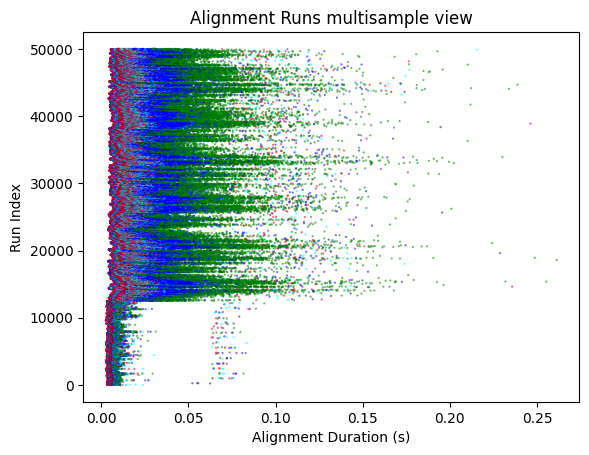

In [5]:
from tqdm import tqdm
total = len(run_dataset)
label_to_color = {'Variants.VERSION_DIJKSTRA_NO_HEURISTICS': 'red',
                  'Variants.VERSION_REMAINING_TRACE': 'purple',
                  'Variants.VERSION_REQUIRED_ACTIVITIES': 'cyan',
                'Variants.VERSION_STATE_EQUATION_A_STAR_ILP': 'blue',
                'Variants.VERSION_STATE_EQUATION_A_STAR': 'green',
                'Variants.VERSION_INCREMENTAL_A_STAR': 'orange'
                }

durations = []
indices   = []
colors    = []

for i, item in tqdm(enumerate(run_dataset), total=len(run_dataset)):
    d = [p.duration for p in item.perf]
    n = len(d)

    durations.extend(d)
    indices.extend([i] * n)
    colors.extend([label_to_color[item.algo]] * n)   # one color per point

durations = np.array(durations)
indices   = np.array(indices)
colors    = np.array(colors)

plt.scatter(
    durations,
    indices,
    c=colors,          # direct color array instead of numeric colormap
    s=0.4,
    alpha=0.5
)

plt.title("Alignment Runs multisample view")
plt.xlabel("Alignment Duration (s)")
plt.ylabel("Run Index")
plt.show()

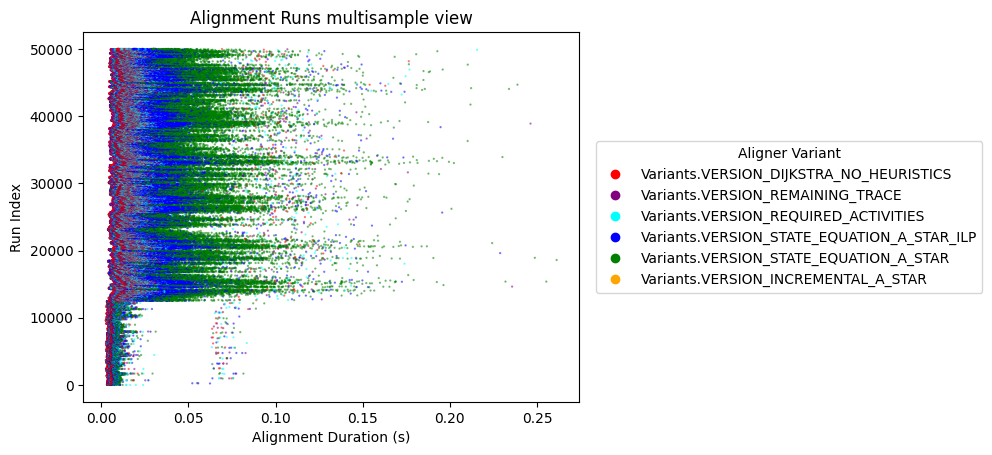

In [6]:
# --- legend creation (no re-plotting) ---
handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                      color=color, markersize=6, label=label)
           for label, color in label_to_color.items()]

plt.legend(handles=handles, title="Aligner Variant",
           loc='center left', bbox_to_anchor=(1.02, 0.5))
#  ↑ pushes the legend *outside* the plot so tiny points remain visible

plt.scatter(
    durations,
    indices,
    c=colors,          # direct color array instead of numeric colormap
    s=0.4,
    alpha=0.5
)

plt.title("Alignment Runs multisample view")
plt.xlabel("Alignment Duration (s)")
plt.ylabel("Run Index")
plt.show()

In [7]:
from dataloaders.runs import PerfCounter

def get_stats(stats: list[PerfCounter]) -> dict[str, float]:
    durations = [s.duration for s in stats if s.duration is not None]
    ms = [s.extract_metrics() for s in stats]
    search_times = [s["search_time"] for s in ms]
    lp_times = [s["lp_time"] for s in ms]

    def compute_metrics(data: list[float]) -> dict[str, float]:
        return {
            "mean": float(np.mean(data)) if data else 0.0,
            "std": float(np.std(data)) if data else 0.0,
            "median": float(np.median(data)) if data else 0.0,
        }

    return {
        "mean_total": compute_metrics(durations)["mean"],
        "std_total": compute_metrics(durations)["std"],
        "median_total": compute_metrics(durations)["median"],
        "mean_search": compute_metrics(search_times)["mean"],
        "std_search": compute_metrics(search_times)["std"],
        "median_search": compute_metrics(search_times)["median"],
        "mean_lp": compute_metrics(lp_times)["mean"],
        "std_lp": compute_metrics(lp_times)["std"],
        "median_lp": compute_metrics(lp_times)["median"],
    }

def format_row(
    run: RunDataset.ItemType, feature_vector: np.typing.NDArray[np.float32]
) -> pd.Series:
    stats = get_stats(run.perf)

    return pd.Series(
        {
            "item_id": run.item_id,
            "combination_id": run.comb_id,
            "model_id": run.model.hash(),
            "trace_id": RunDataset._hash_trace(run.trace),
            "aligner": run.algo,
            "feature_vector": feature_vector,
            # metric for decision making
            "time_total_mean": stats.get("mean_total"),
            "time_total_std": stats.get("std_total"),
            "time_total_median": stats.get("median_total"),
            # breakdown metrics
            "time_search_mean": stats.get("mean_search"),
            "time_lp_mean": stats.get("mean_lp"),
        }
    )

In [8]:
# df_l = pd.read_csv('../../../test_labels.csv')
# df_l.head()

df_l = pd.DataFrame(
    columns=[
        "item_id",
        "combination_id",
        "model_id",
        "trace_id",
        "aligner",
        "feature_vector",
        "time_total_mean",
        "time_total_std",
        "time_total_median",
        "time_search_mean",
        "time_lp_mean",
    ]
)
for run in tqdm(run_dataset, desc="Extracting features from runs"):
    fv = [0.0]
    row = format_row(run, fv)
    df_l = pd.concat([df_l, pd.DataFrame([row])], ignore_index=True)

Extracting features from runs:   0%|          | 0/50000 [00:00<?, ?it/s]/var/folders/9_/r8063ml13sb8gvbk3gkb_l0w0000gn/T/ipykernel_42468/3326748036.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_l = pd.concat([df_l, pd.DataFrame([row])], ignore_index=True)
Extracting features from runs: 100%|██████████| 50000/50000 [03:43<00:00, 224.04it/s]


In [9]:
best_indices = df_l.groupby("combination_id")["time_total_mean"].idxmin()
df_labels = df_l.loc[best_indices]

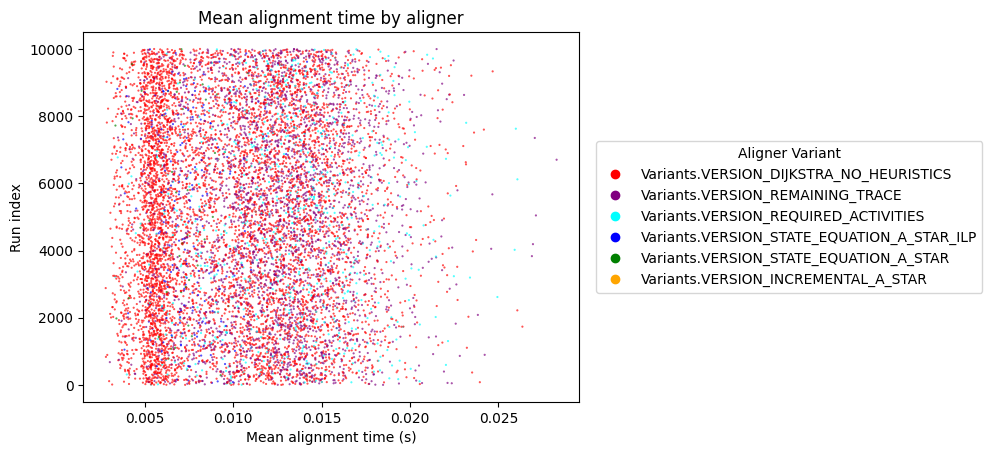

In [11]:
label_to_int = {k: i for i, k in enumerate(label_to_color.keys())}
df_labels['label'] = df_labels['aligner'].map(label_to_int)

# Vectorized extraction
times  = df_labels['time_total_mean'].to_numpy()
indices = np.arange(len(df_labels))                # 0..N-1 without Python looping
colors = df_labels['aligner'].map(label_to_color).to_numpy()



# Single scatter, all data at once
plt.scatter(times, indices, c=colors, s=0.3, alpha=0.7)

# --- legend creation (no re-plotting) ---
handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                      color=color, markersize=6, label=label)
           for label, color in label_to_color.items()]

plt.legend(handles=handles, title="Aligner Variant",
           loc='center left', bbox_to_anchor=(1.02, 0.5))
#  ↑ pushes the legend *outside* the plot so tiny points remain visible

plt.title('Mean alignment time by aligner')
plt.xlabel('Mean alignment time (s)')
plt.ylabel('Run index')
plt.show()

In [13]:
df_labels["aligner"].value_counts()

aligner
Variants.VERSION_DIJKSTRA_NO_HEURISTICS       6280
Variants.VERSION_REMAINING_TRACE              2812
Variants.VERSION_REQUIRED_ACTIVITIES           666
Variants.VERSION_STATE_EQUATION_A_STAR_ILP     199
Variants.VERSION_STATE_EQUATION_A_STAR          43
Name: count, dtype: int64